# Linear Discriminant Analysis

In [8]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, precision_score
from sklearn.metrics import confusion_matrix
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline
plt.style.use('seaborn-v0_8-white')

In [4]:
df = pd.read_csv('Data/Default.csv')
df['student2'] = df.student.factorize()[0]
df['default2'] = df.default.factorize()[0]
df=df.drop(['default','student'],axis=1)
df.head()

,balance,income,student2,default2
0,729.526495,44361.625074,0,0
1,817.180407,12106.134700,1,0
2,1073.549164,31767.138947,0,0
3,529.250605,35704.493935,0,0
4,785.655883,38463.495879,0,0


In [9]:
X = df[['balance', 'income']].values
y = df.default2.values

In [10]:
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X, y)
y_pred = lda.predict(X)

### Công thức phân loại LDA với 2 biến (balance & income)

Tổ hợp tuyến tính $z$:
$$z = -9.8646 + 0.004672 \cdot \text{balance} + 0.00001632 \cdot \text{income}$$

Quy tắc phân loại:
- Nếu $z \ge 0 \implies \hat{y} = 1$ (Vỡ nợ / Default)
- Nếu $z < 0 \implies \hat{y} = 0$ (Không vỡ nợ / No Default)

Phương trình đường ranh giới quyết định ($z = 0$):
$$\text{income} = \frac{9.8646 - 0.004672 \cdot \text{balance}}{0.00001632}$$


Hệ số chặn (intercept): [-9.86455841]
Hệ số góc (coef): [[4.67164553e-03 1.63202568e-05]]


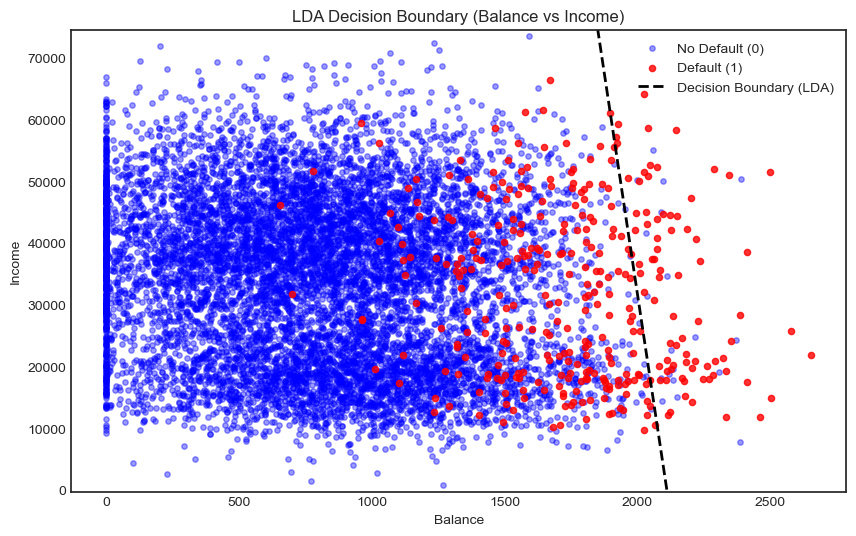

In [13]:
# In hệ số mô hình LDA 2 biến
print("Hệ số chặn (intercept):", lda.intercept_)
print("Hệ số góc (coef):", lda.coef_)

# Vẽ biểu đồ đường ranh giới quyết định LDA cho 2 biến balance và income
plt.figure(figsize=(10, 6))
id0 = (y == 0)
id1 = (y == 1)
plt.scatter(X[id0, 0], X[id0, 1], c='blue', label='No Default (0)', alpha=0.4, s=15)
plt.scatter(X[id1, 0], X[id1, 1], c='red', label='Default (1)', alpha=0.8, s=20)

w = lda.coef_[0]
b = lda.intercept_[0]
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals, color='black', linestyle='--', linewidth=2, label='Decision Boundary (LDA)')
plt.xlabel('Balance')
plt.ylabel('Income')
plt.ylim(X[:, 1].min() - 1000, X[:, 1].max() + 1000)
plt.title('LDA Decision Boundary (Balance vs Income)')
plt.legend()
plt.show()


<Figure size 800x800 with 0 Axes>

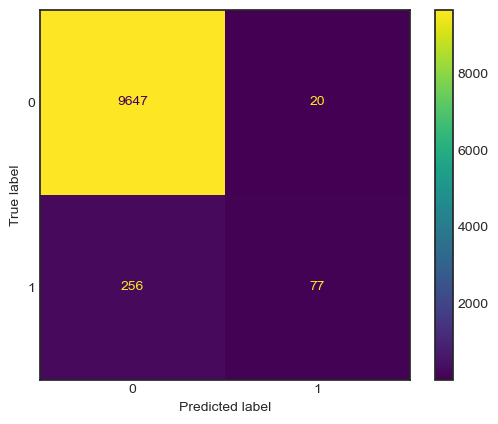

In [11]:
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(lda,X,y)
plt.show()

In [12]:
print(classification_report(y, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.97      1.00      0.99      9667
         Yes       0.79      0.23      0.36       333

    accuracy                           0.97     10000
   macro avg       0.88      0.61      0.67     10000
weighted avg       0.97      0.97      0.96     10000



# Quandratic Discriminant Analysis

In [7]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)
pred = qda.predict(X)

<Figure size 576x576 with 0 Axes>

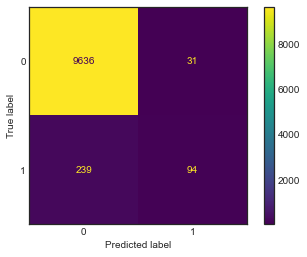

In [8]:
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(qda,X,y)
plt.show()

In [9]:
print(classification_report(y, y_pred, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.97      1.00      0.99      9667
         Yes       0.78      0.24      0.36       333

    accuracy                           0.97     10000
   macro avg       0.88      0.62      0.67     10000
weighted avg       0.97      0.97      0.97     10000



# Naive Bayes

In [10]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB

In [11]:
X, y = load_iris(return_X_y=True)

In [12]:
gnb = GaussianNB()
gnb.fit(X, y)
y_pred = gnb.predict(X)

<Figure size 576x576 with 0 Axes>

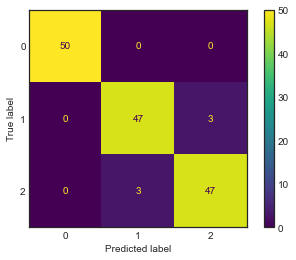

In [13]:
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay.from_estimator(gnb,X,y)
plt.show()

In [14]:
print(classification_report(y, y_pred, target_names=['0', '1','2']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



# So sánh công thức và biểu đồ ranh giới phân loại: LDA, QDA và Naive Bayes

### 1. Công thức lý thuyết của 3 mô hình:

- **LDA (Linear Discriminant Analysis):**
  - **Giả định:** Các lớp dùng chung ma trận hiệp phương sai ($\mathbf{\Sigma}_0 = \mathbf{\Sigma}_1 = \mathbf{\Sigma}$).
  - **Hàm phân biệt:** $\delta_k(x) = x^T \mathbf{\Sigma}^{-1} \mu_k - \frac{1}{2} \mu_k^T \mathbf{\Sigma}^{-1} \mu_k + \ln(\pi_k)$
  - **Ranh giới quyết định:** **Đường thẳng (Tuyến tính)**.

- **QDA (Quadratic Discriminant Analysis):**
  - **Giả định:** Mỗi lớp $k$ có ma trận hiệp phương sai riêng ($\mathbf{\Sigma}_k$).
  - **Hàm phân biệt:** $\delta_k(x) = -\frac{1}{2} \ln |\mathbf{\Sigma}_k| - \frac{1}{2} (x - \mu_k)^T \mathbf{\Sigma}_k^{-1} (x - \mu_k) + \ln(\pi_k)$
  - **Ranh giới quyết định:** **Đường cong bậc hai (Parabol, Ellipse, Hyperbol)**.

- **Naive Bayes (Gaussian Naive Bayes):**
  - **Giả định:** Các thuộc tính độc lập khi biết lớp $k$ (Ma trận hiệp phương sai dạng đường chéo $\mathbf{\Sigma}_k = \text{diag}(\sigma_{k1}^2, \dots, \sigma_{kp}^2)$).
  - **Phân phối xác suất:** $P(x_j \mid y=k) = \frac{1}{\sqrt{2\pi \sigma_{kj}^2}} \exp\left(-\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2}\right)$
  - **Hàm hậu phương:** $P(y=k \mid x) = \frac{\pi_k \prod_{j=1}^p P(x_j \mid y=k)}{\sum_l \pi_l \prod_{j=1}^p P(x_j \mid y=l)}$


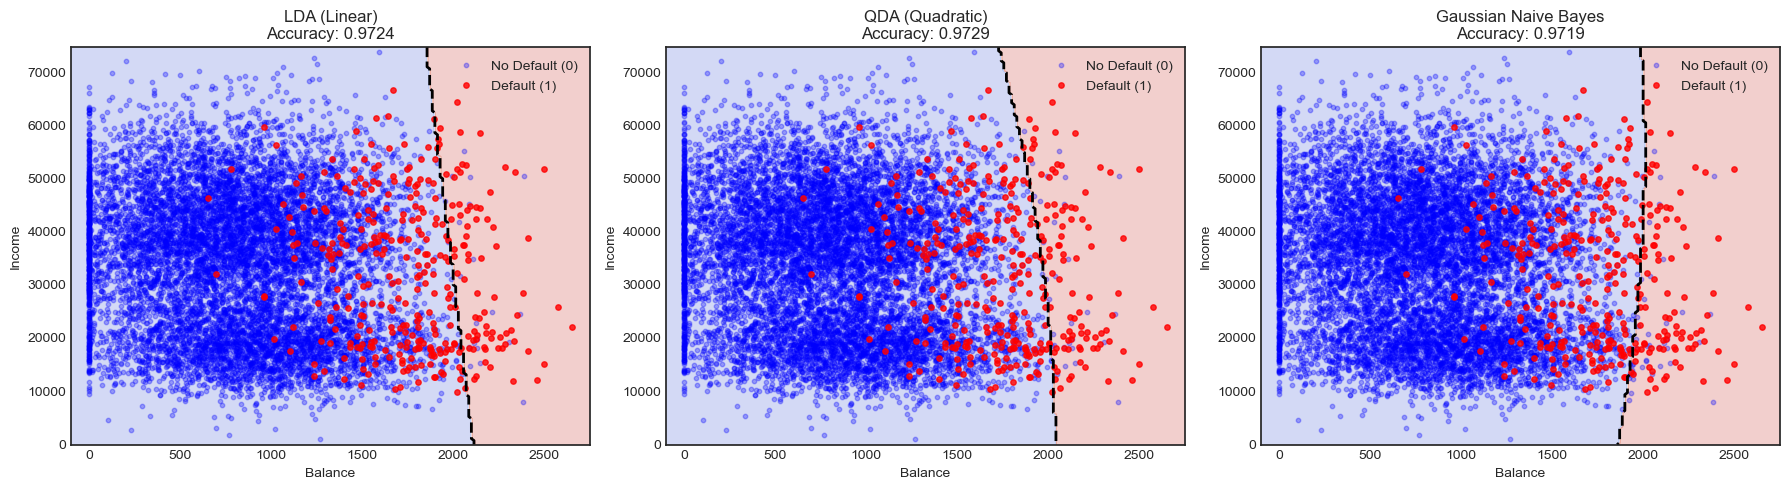

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

# Dữ liệu 2 biến balance và income
X = df[['balance', 'income']].values
y = df.default2.values

# Khởi tạo 3 mô hình
models = {
    'LDA (Linear)': LinearDiscriminantAnalysis(),
    'QDA (Quadratic)': QuadraticDiscriminantAnalysis(),
    'Gaussian Naive Bayes': GaussianNB()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_min, x_max = X[:, 0].min() - 100, X[:, 0].max() + 100
y_min, y_max = X[:, 1].min() - 1000, X[:, 1].max() + 1000
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

id0 = (y == 0)
id1 = (y == 1)

for ax, (name, clf) in zip(axes, models.items()):
    clf.fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Vẽ vùng quyết định (Decision Region)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    
    # Vẽ đường ranh giới quyết định (Decision Boundary)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
    
    # Vẽ các điểm dữ liệu thực tế (màu xanh: No default, màu đỏ: Default)
    ax.scatter(X[id0, 0], X[id0, 1], c='blue', alpha=0.3, s=10, label='No Default (0)')
    ax.scatter(X[id1, 0], X[id1, 1], c='red', alpha=0.8, s=15, label='Default (1)')
    
    acc = clf.score(X, y)
    ax.set_title(f"{name}\nAccuracy: {acc:.4f}", fontsize=12)
    ax.set_xlabel('Balance')
    ax.set_ylabel('Income')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
